<a href="https://colab.research.google.com/github/via-zhang/data-workshops/blob/main/docs/intro_census_data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Intro to Census Data with Python

**To run the code:**
> Make sure you have this notebook open in Google Colab (if you are starting from the digital textbook, click on the {fa}`rocket` icon to the top right and click **Colab**). Each block of code is called a cell. To run a cell, hover over it and click the arrow in the top left of the cell, or click inside of the cell and press Shift + Enter.

Note: When you run a block of code for the first time, Google Colab will say `Warning: This notebook was not authored by Google`. Please click `Run Anyway`.

Sign up for a [Census API key](https://api.census.gov/data/key_signup.html) here. It may take some time for you to receive the email to activate the API key, so this tutorial notebook is divided into two sections: 1. Without API Key and 2. With API Key.

## Without API Key: pygris
- [More information about pygris](https://walker-data.com/pygris/03-data-utilities/)

In [ ]:
#@title Import modules
!pip install -q pygris
from pygris import validate_state, tracts
from pygris.data import get_census
import matplotlib.pyplot as plt

Get outlines of Census Tracts within Orange County

Using FIPS code '12' for input 'FL'
Using FIPS code '095' for input 'Orange'


<Axes: >

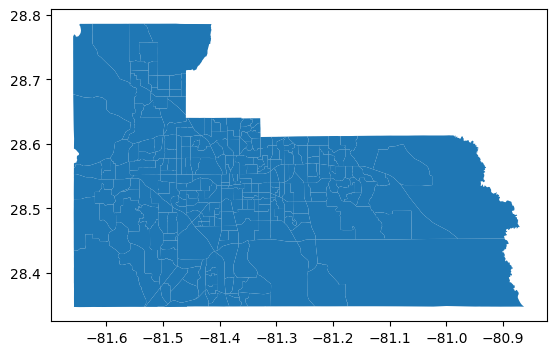

In [ ]:
tracts = tracts(state = "FL",
                county = ['Orange'],
                year = 2023)

tracts.plot()

In Census data, there are unique variable names for hundreds of different datasets. Go to this list of [Census variables](https://api.census.gov/data/2023/acs/acs5/variables.html) and find the codes that align with your topic. Add these codes, along with what you want the column name to be, using the format below:

```
census_vars = {
    "CENSUS_CODE": "NAME_OF_YOUR_COLUMN",
    "CENSUS_CODE": "NAME_OF_YOUR_COLUMN",
    etc...
}
```

If you're not sure which Census variables to use, here is a starting point
```
census_vars = {
    "B01003_001E": 'TOT_POP',
    "C17002_001E": 'INCOME_POVERTY_RATIO',
    "B19058_001E": 'TOT_FOOD_ASSIST',
    "B01002_001E": 'MEDIAN_AGE',
    "B19013_001E": 'MEDIAN_HOUSEHOLD_INCOME',
}
```
| Census Variable | Description |
| :------- | :------: |
| B01003_001E | Total Population |
| C17002_001E | Ratio of Income to Poverty Level in the Past 12 Months |
| B19058_001E | Total Public Assistance Income or Food Stamps/SNAP in the Past 12 Months for Households |
| B01002_001E | Median Age |
| B19013_001E | Median Household Income in the Past 12 Months (in 2023 Inflation-Adjusted Dollars) |

In [ ]:
# Enter your code here
census_vars = {
    
}

census_data = get_census(dataset = "acs/acs5",
                           variables = list(census_vars.keys()),
                           year = 2023,
                           params = {
                             "for": "tract:*",
                             "in": f"state:{validate_state('FL')}"},
                           guess_dtypes = True,
                           return_geoid = True).rename(columns=census_vars)

census_data.head()

### Example:

In [ ]:
census_vars = {
    "B01003_001E": 'TOT_POP',
    "C17002_001E": 'INCOME_POVERTY_RATIO',
    "B19058_001E": 'TOT_FOOD_ASSIST',
    "B01002_001E": 'MEDIAN_AGE',
    "B19013_001E": 'MEDIAN_HOUSEHOLD_INCOME',
}

census_data = get_census(dataset = "acs/acs5",
                           variables = list(census_vars.keys()),
                           year = 2023,
                           params = {
                             "for": "tract:*",
                             "in": f"state:{validate_state('FL')}"},
                           guess_dtypes = True,
                           return_geoid = True).rename(columns=census_vars)

census_data.head()

Using FIPS code '12' for input 'FL'


,TOT_POP,INCOME_POVERTY_RATIO,TOT_FOOD_ASSIST,MEDIAN_AGE,MEDIAN_HOUSEHOLD_INCOME,GEOID
0,5187,5006,2319,21.5,18657.0,12001000201
1,5897,4509,1897,21.4,17609.0,12001000202
2,3703,3703,1855,27.5,47813.0,12001000301
3,2500,2500,1255,47.0,39583.0,12001000302
4,5736,5736,2414,31.8,51266.0,12001000400


To visualize these variables on a map, we can merge `census_data` with `tracts`.

In [ ]:
data = tracts[['geometry', 'GEOID']].merge(census_data, on = "GEOID")
data

,geometry,GEOID,TOT_POP,INCOME_POVERTY_RATIO,TOT_FOOD_ASSIST,MEDIAN_AGE,MEDIAN_HOUSEHOLD_INCOME
0,"POLYGON ((-81.44831 28.59645, -81.44831 28.596...",12095012405,5004,5003,2029,31.9,43411.0
1,"POLYGON ((-81.55755 28.7129, -81.55751 28.7129...",12095017812,7675,7675,2823,41.6,106974.0
2,"POLYGON ((-81.16011 28.5043, -81.16001 28.5043...",12095016750,12628,12600,4188,38.2,113182.0
3,"POLYGON ((-81.27566 28.46595, -81.27561 28.465...",12095016756,2851,2851,953,42.5,150532.0
4,"POLYGON ((-81.51742 28.57588, -81.51741 28.576...",12095015005,3061,3015,1085,44.9,102202.0
...,...,...,...,...,...,...,...
262,"POLYGON ((-81.24514 28.58933, -81.24514 28.589...",12095016504,5370,5180,1886,32.7,58125.0
263,"POLYGON ((-81.245 28.57761, -81.24464 28.57761...",12095016505,2574,2574,1059,29.6,59735.0
264,"POLYGON ((-81.43318 28.49325, -81.43289 28.493...",12095014504,5583,5556,2564,31.5,59000.0
265,"POLYGON ((-81.21225 28.52589, -81.21224 28.526...",12095016731,7530,5111,1874,32.3,90625.0


Text(0.5, 1.0, 'Median Household Income in Orange County, FL (2023)')

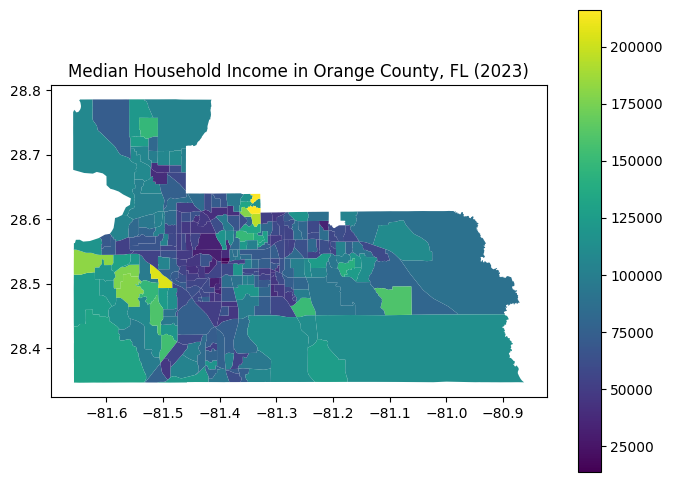

In [ ]:
# Plot the data
data.plot(
    column = "MEDIAN_HOUSEHOLD_INCOME",
    cmap = "viridis",
    figsize = (8, 6),
    legend = True
)

plt.title("Median Household Income in Orange County, FL (2023)")

## With API Key: cenpy
- [More information about cenpy](https://cenpy-devs.github.io/cenpy/)
- Sign up for a [Census API key](https://api.census.gov/data/key_signup.html) here.

In [ ]:
#@title Import modules
!pip install -q pytidycensus
import matplotlib.pyplot as plt
import pandas as pd
import geopandas as gpd
import pytidycensus as tc
import os

In [ ]:
# Set your API key (http://api.census.gov/data/key_signup.html)
tc.set_census_api_key("CENSUS API KEY HERE")

Census API key has been set for this session.


In Census data, there are unique variable names for hundreds of different datasets. Go to this list of [Census variables](https://api.census.gov/data/2023/acs/acs5/variables.html) and find the codes that align with your topic. Add these codes, along with what you want the column name to be, using the format below:

```
census_vars = {
    "CENSUS_CODE": "NAME_OF_YOUR_COLUMN",
    "CENSUS_CODE": "NAME_OF_YOUR_COLUMN",
    etc...
}
```

If you're not sure which Census variables to use, here is a starting point
```
census_vars = {
    "B01003_001E": 'TOT_POP',
    "C17002_001E": 'INCOME_POVERTY_RATIO',
    "B19058_001E": 'TOT_FOOD_ASSIST',
    "B01002_001E": 'MEDIAN_AGE',
    "B19013_001E": 'MEDIAN_HOUSEHOLD_INCOME',
}
```
| Census Variable | Description |
| :------- | :------: |
| B01003_001E | Total Population |
| C17002_001E | Ratio of Income to Poverty Level in the Past 12 Months |
| B19058_001E | Total Public Assistance Income or Food Stamps/SNAP in the Past 12 Months for Households |
| B01002_001E | Median Age |
| B19013_001E | Median Household Income in the Past 12 Months (in 2023 Inflation-Adjusted Dollars) |

In [ ]:
census_vars = {
    "B01003_001E": 'TOT_POP',
    "C17002_001E": 'INCOME_POVERTY_RATIO',
    "B19058_001E": 'TOT_FOOD_ASSIST',
    "B01002_001E": 'MEDIAN_AGE',
    "B19013_001E": 'MEDIAN_HOUSEHOLD_INCOME',
}

census_data = tc.get_acs(
    geography="tract",
    variables=list(census_vars.keys()),
    state="FL",
    year=2023,
    output="wide",
    geometry=True
).rename(columns=census_vars)

Getting data from the 2019-2023 5-year ACS


In [ ]:
census_data

,GEOID,geometry,TOT_POP,INCOME_POVERTY_RATIO,TOT_FOOD_ASSIST,MEDIAN_AGE,MEDIAN_HOUSEHOLD_INCOME,state,county,tract,NAME,B01003_001_moe,C17002_001_moe,B19058_001_moe,B01002_001_moe,B19013_001_moe
0,12031013200,"POLYGON ((-81.70785 30.20086, -81.70756 30.202...",2388,1235,363,22.0,60292,12,031,013200,"Duval County, Florida",336.0,329.0,87.0,0.8,21878.0
1,12031002901,"POLYGON ((-81.68865 30.36574, -81.68582 30.368...",3358,3354,1379,37.2,29125,12,031,002901,"Duval County, Florida",510.0,511.0,146.0,5.7,12349.0
2,12031012000,"POLYGON ((-81.78369 30.30049, -81.78349 30.306...",5801,5794,1895,32.5,56465,12,031,012000,"Duval County, Florida",872.0,872.0,211.0,6.8,16803.0
3,12031012900,"POLYGON ((-81.75218 30.27017, -81.74757 30.270...",2665,2665,1024,36.6,52830,12,031,012900,"Duval County, Florida",458.0,458.0,169.0,5.7,9047.0
4,12031015200,"POLYGON ((-81.60274 30.34624, -81.60262 30.350...",3640,3640,1554,37.7,58932,12,031,015200,"Duval County, Florida",558.0,558.0,323.0,2.3,2260.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5117,12009069906,"POLYGON ((-80.71489 28.387, -80.70295 28.38705...",2064,1931,757,28.9,29163,12,009,069906,"Brevard County, Florida",631.0,630.0,169.0,11.7,5135.0
5118,12111382012,"POLYGON ((-80.34961 27.29706, -80.34957 27.301...",6055,6055,2245,38.5,64409,12,111,382012,"St. Lucie County, Florida",791.0,791.0,265.0,3.7,12236.0
5119,12095014201,"POLYGON ((-81.40092 28.45036, -81.40028 28.452...",6345,6215,1831,33.9,65181,12,095,014201,"Orange County, Florida",1673.0,1668.0,417.0,4.3,29441.0
5120,12091022500,"POLYGON ((-86.63945 30.42761, -86.63841 30.428...",4316,4316,1675,37.3,81313,12,091,022500,"Okaloosa County, Florida",461.0,461.0,178.0,1.7,17276.0


In [ ]:
# Filter Census data to Orange County
data = census_data[census_data['GEOID'].str.startswith('120950')]
data

,GEOID,geometry,TOT_POP,INCOME_POVERTY_RATIO,TOT_FOOD_ASSIST,MEDIAN_AGE,MEDIAN_HOUSEHOLD_INCOME,state,county,tract,NAME,B01003_001_moe,C17002_001_moe,B19058_001_moe,B01002_001_moe,B19013_001_moe
45,12095014601,"POLYGON ((-81.45939 28.53206, -81.45826 28.537...",8356,8356,2599,29.5,45488,12,095,014601,"Orange County, Florida",1209.0,1209.0,372.0,2.0,15543.0
46,12095017807,"POLYGON ((-81.48867 28.68386, -81.4763 28.6838...",4506,4506,1428,37.5,61115,12,095,017807,"Orange County, Florida",723.0,723.0,190.0,5.3,9928.0
47,12095012000,"POLYGON ((-81.45219 28.57339, -81.4515 28.5780...",9327,9153,2301,29.8,54163,12,095,012000,"Orange County, Florida",1831.0,1649.0,183.0,2.3,7573.0
48,12095014702,"POLYGON ((-81.47583 28.5391, -81.46761 28.5382...",5345,5306,2139,34.2,50908,12,095,014702,"Orange County, Florida",680.0,680.0,247.0,1.7,5445.0
49,12095014811,"POLYGON ((-81.4919 28.48467, -81.49159 28.4886...",4704,4704,1864,46.5,113509,12,095,014811,"Orange County, Florida",565.0,565.0,225.0,3.0,24825.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5036,12095012307,"POLYGON ((-81.46787 28.59614, -81.46123 28.596...",6867,6821,2313,35.2,47378,12,095,012307,"Orange County, Florida",831.0,832.0,206.0,3.4,8875.0
5059,12095016723,"POLYGON ((-81.24486 28.56928, -81.23741 28.569...",5787,5750,1670,38.1,82500,12,095,016723,"Orange County, Florida",740.0,737.0,126.0,2.6,16686.0
5072,12095016746,"POLYGON ((-81.19469 28.54369, -81.18831 28.543...",4486,4486,1473,46.3,99959,12,095,016746,"Orange County, Florida",960.0,960.0,262.0,2.6,35486.0
5100,12095015702,"POLYGON ((-81.34502 28.62161, -81.34479 28.622...",1520,1520,588,41.3,117237,12,095,015702,"Orange County, Florida",195.0,195.0,71.0,3.5,38055.0


Text(0.5, 1.0, 'Median Household Income in Orange County, FL (2023)')

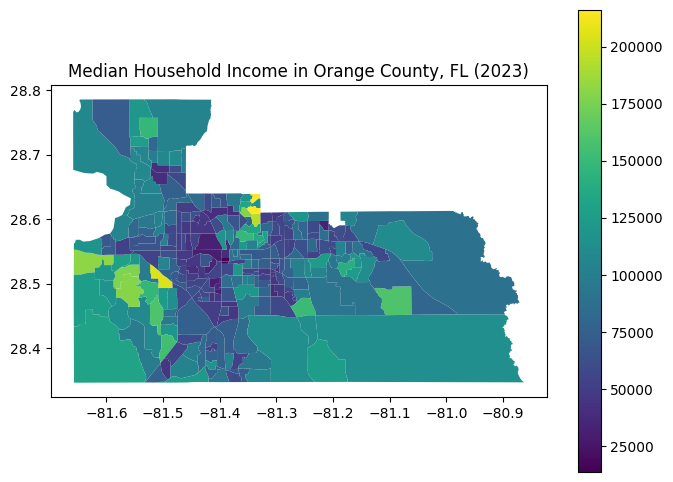

In [ ]:
# Convert columns to numeric
for col in list(census_vars.values()):
  data[col] = pd.to_numeric(data[col])

# Plot the data
data.plot(
    column = "MEDIAN_HOUSEHOLD_INCOME",
    cmap = "viridis",
    figsize = (8, 6),
    legend = True
)

plt.title("Median Household Income in Orange County, FL (2023)")